In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

In [2]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

speed_threshold = 3

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled


In [3]:
# Find and load all theta_amp_speed*.npz files (in/out place field)
pattern = os.path.join(data_folder, 'CKII**', f'theta_amp_speed{speed_threshold}.npz')
npz_files = glob.glob(pattern, recursive=True)
print(f'Found {len(npz_files)} theta_amp files:')
for f in npz_files:
    print(f'  {f}')

# Pool data from all datasets
theta_run_in_all = []
theta_run_out_all = []
theta_rest_in_all = []
theta_rest_out_all = []

for npz_path in npz_files:
    data = np.load(npz_path)
    theta_run_in_all.append(data['theta_run_in'])
    theta_run_out_all.append(data['theta_run_out'])
    theta_rest_in_all.append(data['theta_rest_in'])
    theta_rest_out_all.append(data['theta_rest_out'])
    print(f'Loaded {os.path.basename(os.path.dirname(npz_path))}: {len(data["theta_run_in"])} cells')

# Concatenate all data
theta_run_in = np.concatenate(theta_run_in_all) if theta_run_in_all else np.array([])
theta_run_out = np.concatenate(theta_run_out_all) if theta_run_out_all else np.array([])
theta_rest_in = np.concatenate(theta_rest_in_all) if theta_rest_in_all else np.array([])
theta_rest_out = np.concatenate(theta_rest_out_all) if theta_rest_out_all else np.array([])

print(f'\nTotal pooled place cells: {len(theta_run_in)}')

Found 3 theta_amp files:
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce21_PR_20250806/theta_amp_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce45_PX_20260118/theta_amp_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/theta_amp_speed3.npz
Loaded CKII_pAce21_PR_20250806: 3 cells
Loaded CKII_pAce45_PX_20260118: 4 cells
Loaded CKII_pAce38_PX_20251126: 7 cells

Total pooled place cells: 14


In [4]:
# Helper functions for statistical tests and plotting

def _paired_test(vals_in, vals_out):
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = stats.wilcoxon(paired_in[valid], paired_out[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

def _global_ylim(arrays, pad_frac=0.08):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0:
            continue
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            vals.append(finite)
    if not vals:
        return None
    merged = np.concatenate(vals)
    y_min = np.nanmin(merged)
    y_max = np.nanmax(merged)
    y_span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * y_span
    return y_min - pad, y_max + pad

Locomotion theta amp (paired t-test): n=14, stat=4.6, p=0.000495, shapiro_p=0.664
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/ThetaAmp_in_out_PF_run_pooled.svg


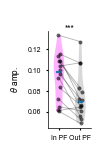

Quiet theta amp (paired t-test): n=14, stat=1.6, p=0.133, shapiro_p=0.357
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/ThetaAmp_in_out_PF_rest_pooled.svg


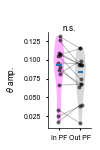

In [5]:
# Plot theta amplitude: In PF vs Out PF (Locomotion and Quiet)

panel_w = 1.0
panel_h = 1.5
xlim = (0.5, 2.5)

theta_ylim = _global_ylim([
    theta_run_in,
    theta_run_out,
    theta_rest_in,
    theta_rest_out,
])

state_specs = [
    ('run', 'Locomotion', np.asarray(theta_run_in, dtype=float), np.asarray(theta_run_out, dtype=float)),
    ('rest', 'Quiet', np.asarray(theta_rest_in, dtype=float), np.asarray(theta_rest_out, dtype=float)),
]

for state_key, state_label, vals_in, vals_out in state_specs:
    fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h), sharex=True, sharey=True)
    plot_data = []
    for vals in [vals_in, vals_out]:
        finite = vals[np.isfinite(vals)]
        if finite.size == 0:
            finite = np.array([np.nan])
        plot_data.append(finite)

    parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
    for body in parts['bodies']:
        body.set_alpha(0.3)
    if len(parts['bodies']) >= 2:
        parts['bodies'][0].set_facecolor('magenta')
        parts['bodies'][1].set_facecolor('gray')
        parts['bodies'][0].set_edgecolor('none')
        parts['bodies'][1].set_edgecolor('none')

    n_pairs = min(len(vals_in), len(vals_out))
    for i in range(n_pairs):
        if np.isfinite(vals_in[i]) and np.isfinite(vals_out[i]):
            ax.plot(
                [1, 2],
                [vals_in[i], vals_out[i]],
                color='black',
                alpha=0.3,
                linewidth=0.6,
            )

    rng = np.random.default_rng(0)
    for idx, vals in enumerate([vals_in, vals_out], start=1):
        finite_mask = np.isfinite(vals)
        if not np.any(finite_mask):
            continue
        jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
        xs = idx + jitter
        ax.scatter(
            xs,
            vals[finite_mask],
            s=8,
            color='black',
            alpha=0.6,
            linewidths=0,
        )

    p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in, vals_out)
    sig_label = _sig_label(p_val)
    if np.isfinite(p_val):
        print(
            f"{state_label} theta amp ({test_name}): n={n_valid}, "
            f"stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}"
        )
    else:
        print(f"{state_label} theta amp: n={n_valid} (insufficient valid pairs)")
    if sig_label:
        y_vals = np.concatenate([vals_in[np.isfinite(vals_in)], vals_out[np.isfinite(vals_out)]])
        if y_vals.size > 0:
            y_max = np.nanmax(y_vals)
            y_min = np.nanmin(y_vals)
            y_span = y_max - y_min if y_max != y_min else 1.0
            y_off = 0.08 * y_span
            y_star = y_max + y_off
            if theta_ylim is not None:
                y0, y1 = theta_ylim
                y_span_global = y1 - y0 if y1 != y0 else 1.0
                y_star = min(y_star, y1 - 0.05 * y_span_global)
            ax.text(
                1.5,
                y_star,
                sig_label,
                ha='center',
                va='bottom',
                fontsize=6,
                fontname='Arial',
            )

    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        ['In PF', 'Out PF'],
        fontsize=5,
        fontname='Arial',
    )
    ax.set_ylabel(r'$\theta$ amp.', fontsize=6, fontname='Arial')
    ax.tick_params(labelsize=5)
    ax.set_xlim(*xlim)
    for label in list(ax.get_yticklabels()):
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    theta_violin_out_path = os.path.join(
        figure_save_folder,
        f"ThetaAmp_in_out_PF_{state_key}_pooled.svg",
    )
    fig.savefig(theta_violin_out_path, dpi=300)
    print(f"Saved to {theta_violin_out_path}")
    plt.show()